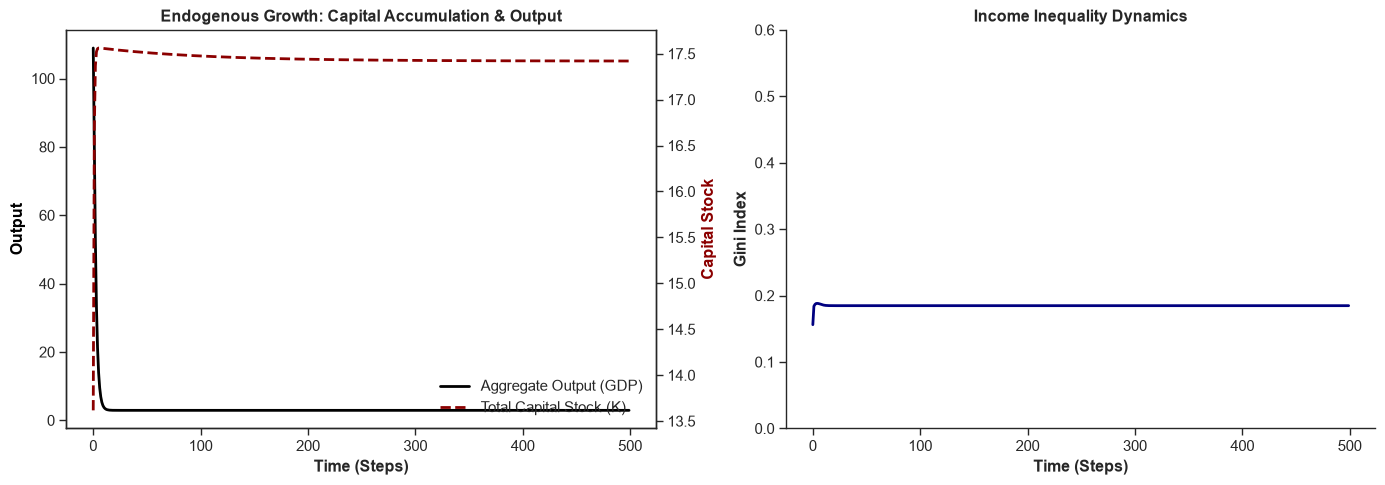

In [3]:
import sys
import os

# Point Python to the 'src' folder which is one directory up from 'notebooks'
sys.path.append(os.path.abspath('C:\\Users\\recursivechaos\\Documents\\ABM\\src'))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from model import MacroModel

# 1. Run the Simulation
# We initialize the model with 100 households, 10 firms, and a 10% capitalist class
model = MacroModel(
    num_firms=10, 
    num_households=100, 
    pct_capitalists=0.10, 
    markup=0.2,       # Increase markup to give capitalists more profit to invest
    theta=0.9,        # Capitalists now reinvest 90% of excess savings (stopping the hoarding leak)
    delta=0.01,       # Lower depreciation to 1% so capital doesn't rot away instantly
    gamma=1.5,        # Make capital highly productive
    alpha=0.5         # Standard Cobb-Douglas capital elasticity
)

steps = 500
for i in range(steps):
    model.step()

# 2. Extract the Data
# Mesa's DataCollector automatically formats our tracking variables into a Pandas DataFrame
df = model.datacollector.get_model_vars_dataframe()

# 3. Visualization Setup (Academic Minimalist Aesthetic)
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Output vs. Capital Accumulation ---
# This proves your extension works: as capital grows, the output gap closes.
ax1 = axes[0]
ax1.plot(df.index, df["Output"], color="black", linewidth=2, label="Aggregate Output (GDP)")
ax1.set_ylabel("Output", color="black", weight="bold")
ax1.set_xlabel("Time (Steps)", weight="bold")

# Create a twin axis to overlay Total Capital on the same graph
ax1_twin = ax1.twinx()
ax1_twin.plot(df.index, df["Total_Capital"], color="darkred", linestyle="--", linewidth=2, label="Total Capital Stock (K)")
ax1_twin.set_ylabel("Capital Stock", color="darkred", weight="bold")

ax1.set_title("Endogenous Growth: Capital Accumulation & Output", weight="bold")
# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="lower right", frameon=False)


# --- Plot 2: Inequality (Gini Index) ---
# This addresses his core finding: showing how inequality stabilizes when wealth is reinvested.
ax2 = axes[1]
ax2.plot(df.index, df["Gini_Index"], color="navy", linewidth=2)
ax2.set_title("Income Inequality Dynamics", weight="bold")
ax2.set_ylabel("Gini Index", weight="bold")
ax2.set_xlabel("Time (Steps)", weight="bold")
ax2.set_ylim(0, 0.6) # Standard Gini bounds for visual clarity

sns.despine(ax=ax1, right=False) # Keep right spine for twin axis
sns.despine(ax=ax2)
plt.tight_layout()
plt.show()